In [2]:
import pandas as pd
import numpy as np
import psycopg2

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

CSV_PATH = r"C:\Users\mariana.kober_involv\challenge\2026_data_challenge_ae_data.csv"
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 5361 rows x 31 columns


,loadsmart_id,lane,quote_date,book_date,source_date,pickup_date,delivery_date,book_price,source_price,pnl,mileage,equipment_type,carrier_rating,sourcing_channel,vip_carrier,carrier_dropped_us_count,carrier_name,shipper_name,carrier_on_time_to_pickup,carrier_on_time_to_delivery,carrier_on_time_overall,pickup_appointment_time,delivery_appointment_time,has_mobile_app_tracking,has_mobile_app_tracking.1,has_macropoint_tracking,has_edi_tracking,contracted_load,load_booked_autonomously,load_sourced_autonomously,load_was_cancelled
0,206431033,"Hood River,OR -> Upper Marlboro,MD",12/15/2024 13:08,12/15/2024 13:09,12/15/2024 13:44,12/15/2024 11:00,12/21/2024 2:00,8922.51,8500.0,422.51,2753.5,RFR,NaN,dat_in,False,0,Carrier 605817,Shipper 758,True,True,True,12/15/2024 20:00,12/21/2024 0:00,False,False,False,False,False,False,False,False
1,206521177,"Etowah,TN -> Reno,NV",11/20/2024 9:32,11/20/2024 9:32,11/21/2024 9:46,11/21/2024 14:00,11/27/2024 16:00,8726.17,4000.0,4726.17,2331.3,DRV,NaN,NaN,False,0,Carrier 1396487,Shipper 1644,True,True,True,11/21/2024 14:00,11/27/2024 17:00,False,False,False,False,False,False,False,False
2,206694049,"Salinas,CA -> Upper Marlboro,MD",6/1/2024 18:04,6/1/2024 18:04,6/2/2024 15:11,6/3/2024 2:00,6/9/2024 4:10,8548.19,8220.0,328.19,3013.4,RFR,NaN,NaN,False,0,Carrier 1044585,Shipper 758,True,True,True,6/3/2024 2:00,6/8/2024 23:00,False,False,False,False,False,False,False,False
3,206553113,"Montpelier,OH -> Reno,NV",11/20/2024 9:10,11/20/2024 9:10,11/20/2024 12:39,11/22/2024 17:00,11/28/2024 19:00,8409.27,5000.0,3409.27,2082.3,DRV,NaN,NaN,False,0,Carrier 738,Shipper 1644,True,True,True,11/22/2024 17:00,11/28/2024 19:00,False,False,False,False,False,False,False,False
4,206518817,"Newark,DE -> Portland,OR",9/25/2024 15:07,9/25/2024 15:07,9/26/2024 9:05,9/26/2024 17:00,10/2/2024 11:55,8351.95,5500.0,2851.95,2847.7,DRV,NaN,NaN,False,0,Carrier 14533,Shipper 1644,True,True,True,9/26/2024 17:00,10/2/2024 10:00,False,False,False,False,False,False,False,False


## 1. Structure and Data Types ## 

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5361 entries, 0 to 5360
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   loadsmart_id                 5361 non-null   int64  
 1   lane                         5361 non-null   str    
 2   quote_date                   5361 non-null   str    
 3   book_date                    5361 non-null   str    
 4   source_date                  3862 non-null   str    
 5   pickup_date                  5361 non-null   str    
 6   delivery_date                5361 non-null   str    
 7   book_price                   5361 non-null   float64
 8   source_price                 5361 non-null   float64
 9   pnl                          5361 non-null   float64
 10  mileage                      5361 non-null   float64
 11  equipment_type               5361 non-null   str    
 12  carrier_rating               747 non-null    float64
 13  sourcing_channel             

## 2. Duplicate Columns

In [4]:
#Duplicate columns
dup_name_cols = [c for c in df.columns if c.endswith('.1') or c.endswith('.2')]
print("Columns that look like duplicated headers:", dup_name_cols)

for c in dup_name_cols:
    base = c.rsplit('.', 1)[0]
    if base in df.columns:
        identical = df[base].equals(df[c])
        print(f"  '{base}' vs '{c}' -> identical values: {identical}")

Columns that look like duplicated headers: ['has_mobile_app_tracking.1']
  'has_mobile_app_tracking' vs 'has_mobile_app_tracking.1' -> identical values: True


## 3. Constant Columns

In [5]:
# Constant columns
constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print("Constant (zero-variance) columns:")
for c in constant_cols:
    print(f"  {c}: only value = {df[c].dropna().unique()}")

Constant (zero-variance) columns:
  has_mobile_app_tracking: only value = [False]
  has_mobile_app_tracking.1: only value = [False]
  has_macropoint_tracking: only value = [False]
  has_edi_tracking: only value = [False]
  contracted_load: only value = [False]


## 4. ID check 

In [14]:
# Fully duplicated rows
n_dupe_rows = df.duplicated().sum()
print(f"Fully duplicated rows: {n_dupe_rows}")

# Duplicated id
n_dupe_ids = df['loadsmart_id'].duplicated().sum()
print(f"Duplicated loadsmart_id values: {n_dupe_ids}")

# Duplicated ID = fully record?
dupe_ids = df[df['loadsmart_id'].duplicated()]['loadsmart_id'].unique()
dupe_rows_df = df[df['loadsmart_id'].isin(dupe_ids)].sort_values('loadsmart_id')
all_dupes_identical = dupe_rows_df.duplicated(keep=False).all()
print(f"\nAre all rows sharing duplicate loadsmart_ids completely identical? {all_dupes_identical}")

# Display the duplicate rows to visually inspect differences
dupe_rows_df

Fully duplicated rows: 4
Duplicated loadsmart_id values: 4

Are all rows sharing duplicate loadsmart_ids completely identical? True


,loadsmart_id,lane,quote_date,book_date,source_date,pickup_date,delivery_date,book_price,source_price,pnl,mileage,equipment_type,carrier_rating,sourcing_channel,vip_carrier,carrier_dropped_us_count,carrier_name,shipper_name,carrier_on_time_to_pickup,carrier_on_time_to_delivery,carrier_on_time_overall,pickup_appointment_time,delivery_appointment_time,has_mobile_app_tracking,has_mobile_app_tracking.1,has_macropoint_tracking,has_edi_tracking,contracted_load,load_booked_autonomously,load_sourced_autonomously,load_was_cancelled
11,206432441,"Trenton,MO -> Reno,NV",12/22/2024 11:35,12/22/2024 11:35,12/22/2024 13:07,12/22/2024 16:00,12/26/2024 13:34,7632.35,6000.0,1632.35,1607.7,DRV,NaN,dat_in,False,0,Carrier 1049651,Shipper 1644,True,True,True,12/22/2024 16:00,12/26/2024 12:00,False,False,False,False,False,False,False,False
71,206432441,"Trenton,MO -> Reno,NV",12/22/2024 11:35,12/22/2024 11:35,12/22/2024 13:07,12/22/2024 16:00,12/26/2024 13:34,7632.35,6000.0,1632.35,1607.7,DRV,NaN,dat_in,False,0,Carrier 1049651,Shipper 1644,True,True,True,12/22/2024 16:00,12/26/2024 12:00,False,False,False,False,False,False,False,False
5258,206437697,"Plant City,FL -> McCook,IL",1/4/2024 16:24,1/4/2024 16:24,NaN,1/23/2024 9:00,1/20/2024 8:53,0.00,0.0,0.00,1180.8,DRV,NaN,NaN,False,2,NaN,Shipper 585,NaN,NaN,NaN,1/23/2024 15:00,1/25/2024 11:00,False,False,False,False,False,False,False,True
5344,206437697,"Plant City,FL -> McCook,IL",1/4/2024 16:24,1/4/2024 16:24,NaN,1/23/2024 9:00,1/20/2024 8:53,0.00,0.0,0.00,1180.8,DRV,NaN,NaN,False,2,NaN,Shipper 585,NaN,NaN,NaN,1/23/2024 15:00,1/25/2024 11:00,False,False,False,False,False,False,False,True
179,206533729,"Compton,CA -> Plant City,FL",12/13/2024 17:46,12/13/2024 17:47,12/14/2024 7:48,12/14/2024 11:00,12/20/2024 12:00,6900.00,6700.0,200.00,2539.7,DRV,NaN,NaN,False,0,Carrier 1467410,Shipper 585,True,False,False,12/14/2024 15:00,12/19/2024 8:00,False,False,False,False,False,False,False,False
34,206533729,"Compton,CA -> Plant City,FL",12/13/2024 17:46,12/13/2024 17:47,12/14/2024 7:48,12/14/2024 11:00,12/20/2024 12:00,6900.00,6700.0,200.00,2539.7,DRV,NaN,NaN,False,0,Carrier 1467410,Shipper 585,True,False,False,12/14/2024 15:00,12/19/2024 8:00,False,False,False,False,False,False,False,False
278,206586825,"Sapulpa,OK -> Warner Robins,GA",12/1/2024 16:15,12/1/2024 16:15,12/4/2024 10:12,12/4/2024 7:00,12/6/2024 10:00,4114.33,3100.0,1014.33,897.0,DRV,NaN,dat_in,False,0,Carrier 84317,Shipper 1249,True,True,True,12/4/2024 22:00,12/6/2024 10:00,False,False,False,False,False,False,False,False
246,206586825,"Sapulpa,OK -> Warner Robins,GA",12/1/2024 16:15,12/1/2024 16:15,12/4/2024 10:12,12/4/2024 7:00,12/6/2024 10:00,4114.33,3100.0,1014.33,897.0,DRV,NaN,dat_in,False,0,Carrier 84317,Shipper 1249,True,True,True,12/4/2024 22:00,12/6/2024 10:00,False,False,False,False,False,False,False,False


## 5. Missing Values


In [8]:
missing_all = df.isna().sum().sort_values(ascending=False)
missing_all_pct = (missing_all / len(df) * 100).round(1)
missing_all_summary = pd.DataFrame({
    'dtype': df.dtypes[missing_all.index].astype(str),
    'missing_count': missing_all,
    'missing_pct': missing_all_pct,
    'non_missing_count': len(df) - missing_all
})
print(f"Total columns: {df.shape[1]} | Columns with at leats one missing value: "
      f"{(missing_all_summary['missing_count'] > 0).sum()}")
display(missing_all_summary)

Total columns: 31 | Columns with at leats one missing value: 7


,dtype,missing_count,missing_pct,non_missing_count
sourcing_channel,str,5117,95.4,244
carrier_rating,float64,4614,86.1,747
source_date,str,1499,28.0,3862
carrier_on_time_to_delivery,object,606,11.3,4755
carrier_on_time_overall,object,606,11.3,4755
carrier_on_time_to_pickup,object,606,11.3,4755
carrier_name,str,499,9.3,4862
delivery_date,str,0,0.0,5361
pickup_date,str,0,0.0,5361
book_price,float64,0,0.0,5361


In [9]:
# Empty values in ALL columns: NaN, None, empty string, whitespaces, and 0 (numeric, except booleans)

def count_empty_like(series):
    """Counts null values, empty/whitespace-only strings, and zero (only for NON-boolean numerics)."""
    is_na = series.isna()

    if pd.api.types.is_bool_dtype(series):
        # Boolean: False is a valid value, it does not count as "empty"
        is_zero = pd.Series(False, index=series.index)
        is_blank_str = pd.Series(False, index=series.index)
    elif pd.api.types.is_numeric_dtype(series):
        is_zero = series == 0
        is_blank_str = pd.Series(False, index=series.index)
    else:
        as_str = series.astype(str).str.strip()
        is_blank_str = as_str.eq('') & ~is_na
        is_zero = pd.Series(False, index=series.index)

    return is_na, is_blank_str, is_zero

rows = []
for col in df.columns:
    is_na, is_blank_str, is_zero = count_empty_like(df[col])
    empty_like = is_na | is_blank_str | is_zero

    rows.append({
        'column': col,
        'dtype': str(df[col].dtype),
        'na_count': is_na.sum(),
        'blank_string_count': is_blank_str.sum(),
        'zero_count': is_zero.sum(),
        'empty_like_total': empty_like.sum(),
        'empty_like_pct': round(empty_like.sum() / len(df) * 100, 1)
    })

empty_all_summary = pd.DataFrame(rows).sort_values('empty_like_total', ascending=False)

print(f"Total columns: {df.shape[1]} | Columns with at least 1 empty/zero/blank value: "
      f"{(empty_all_summary['empty_like_total'] > 0).sum()}")

display(empty_all_summary[empty_all_summary['empty_like_total'] > 0])

Total columns: 31 | Columns with at least 1 empty/zero/blank value: 12


,column,dtype,na_count,blank_string_count,zero_count,empty_like_total,empty_like_pct
13,sourcing_channel,str,5117,0,0,5117,95.4
12,carrier_rating,float64,4614,0,7,4621,86.2
15,carrier_dropped_us_count,int64,0,0,4454,4454,83.1
4,source_date,str,1499,0,0,1499,28.0
9,pnl,float64,0,0,607,607,11.3
18,carrier_on_time_to_pickup,object,606,0,0,606,11.3
20,carrier_on_time_overall,object,606,0,0,606,11.3
19,carrier_on_time_to_delivery,object,606,0,0,606,11.3
7,book_price,float64,0,0,530,530,9.9
8,source_price,float64,0,0,519,519,9.7


## 6. Categorical Columns - Value Inventory


In [5]:
categorical_cols = ['carrier_name', 'shipper_name', 'lane','equipment_type', 'sourcing_channel', 'vip_carrier',
                    'carrier_on_time_to_pickup', 'carrier_on_time_to_delivery', 'carrier_on_time_overall',
                    'load_booked_autonomously', 'load_sourced_autonomously', 'load_was_cancelled',
                    'contracted_load', 'carrier_dropped_us_count', 'carrier_rating']

for c in categorical_cols:
    if c in df.columns:
        print(f"--- {c} ---")
        print(df[c].value_counts(dropna=False))
        print()

--- carrier_name ---
carrier_name
NaN                499
Carrier 567581     188
Carrier 611154     149
Carrier 97236      101
Carrier 804788      89
                  ... 
Carrier 1054148      1
Carrier 1043457      1
Carrier 733897       1
Carrier 736749       1
Carrier 8420         1
Name: count, Length: 2203, dtype: int64

--- shipper_name ---
shipper_name
Shipper 758     2002
Shipper 1249    1253
Shipper 1644     454
Shipper 585      342
Shipper 968      133
                ... 
Shipper 1465       1
Shipper 1303       1
Shipper 1356       1
Shipper 802        1
Shipper 1063       1
Name: count, Length: 94, dtype: int64

--- lane ---
lane
Hawkins,TX -> Roanoke,TX                 949
Lodi,CA -> Pacific,WA                    161
Kent,WA -> Spokane,WA                    113
Henderson,NV -> Tracy,CA                  92
Taft,CA -> Tracy,CA                       73
                                        ... 
Santa Ana,CA -> Fontana,CA                 1
Bethlehem,PA -> Santa Ana,CA       

In [10]:
# Expected pattern: "Origin -> Destination" or "Origin - Destination" (NO numbers)
pattern = r'^[A-Za-z\s,\.-]+\s*(?:->|-)\s*[A-Za-z\s,\.-]+$'

lanes = df['lane'].dropna().astype(str)
invalid_lanes = lanes[~lanes.str.match(pattern)]

print(f"Total invalid lanes (incorrect format or containing numbers): {len(invalid_lanes)}\n")
print("Invalid lane values and counts:")
print(invalid_lanes.value_counts())

Total invalid lanes (incorrect format or containing numbers): 27

Invalid lane values and counts:
lane
1,LA -> Brazil,IN         14
1,LA -> Herculaneum,MO     8
1,LA -> Fleetwood,PA       3
1,LA -> Birmingham,AL      1
1,LA -> Homewood,AL        1
Name: count, dtype: int64


In [8]:
# Aggregate unique values and distinct count per carrier
carrier_summary = df.groupby('carrier_name').agg(
    unique_ratings=('carrier_rating', lambda x: list(x.unique())),
    num_unique_ratings=('carrier_rating', 'nunique'),
    unique_vip_statuses=('vip_carrier', lambda x: list(x.unique())),
    num_unique_vip_statuses=('vip_carrier', 'nunique')
).reset_index()

# Filter where EITHER carrier_rating OR vip_carrier has more than 1 unique value
filtered_summary = carrier_summary.query('num_unique_ratings > 1 or num_unique_vip_statuses > 1')

filtered_summary

,carrier_name,unique_ratings,num_unique_ratings,unique_vip_statuses,num_unique_vip_statuses
19,Carrier 1007131,"[nan, 3.0, 4.0]",2,[False],1
139,Carrier 1037934,"[nan, 3.0, 4.0]",2,[False],1
156,Carrier 1041647,"[3.0, nan, 4.0]",2,[False],1
195,Carrier 104870,"[nan, 4.0, 2.0]",2,[False],1
239,Carrier 1057935,"[nan, 4.0, 3.0]",2,[False],1
...,...,...,...,...,...
2051,Carrier 922672,"[nan, 2.0, 0.0]",2,[False],1
2061,Carrier 93448,"[nan, 3.0, 4.0, 2.0]",3,[False],1
2072,Carrier 941668,"[nan, 3.0, 4.0]",2,[False],1
2086,Carrier 946269,"[4.0, 3.0, nan]",2,[False],1


## 7. Numeric Columns


In [15]:
numeric_cols = ['book_price', 'source_price', 'pnl', 'mileage', 'carrier_rating']
df[numeric_cols].describe()

,book_price,source_price,pnl,mileage,carrier_rating
count,5361.000000,5361.000000,5361.000000,5361.000000,747.000000
mean,1329.134199,1295.788025,33.023414,583.322645,3.330656
std,1300.961840,1244.014315,377.963923,615.867874,0.789787
min,0.000000,0.000000,-3374.440000,0.000000,0.000000
25%,462.070000,450.000000,-45.730000,140.000000,3.000000
50%,882.560000,933.000000,13.970000,365.400000,3.000000
75%,1808.790000,1750.000000,100.000000,766.700000,4.000000
max,8922.510000,11050.000000,4726.170000,3139.000000,5.000000


In [11]:
numeric_cols = ['book_price', 'source_price', 'pnl', 'mileage', 'carrier_rating']

print("Negative values per column:")
print((df[numeric_cols] < 0).sum())

print("\nLines with negative values:")
print(df[df[numeric_cols].lt(0).any(axis=1)][numeric_cols])

Negative values per column:
book_price           0
source_price         0
pnl               1691
mileage              0
carrier_rating       0
dtype: int64

Lines with negative values:
      book_price  source_price      pnl  mileage  carrier_rating
5        8140.88      11050.00 -2909.12   2863.1             NaN
14       7479.33       7500.00   -20.67   3008.0             NaN
15       7475.63       7500.00   -24.37   2948.9             NaN
17       7402.38       7500.00   -97.62   2847.9             NaN
18       7371.42       7500.00  -128.58   2702.1             NaN
...          ...           ...      ...      ...             ...
4796      372.43        500.00  -127.57    105.2             4.0
4823      150.00        150.01    -0.01    130.8             NaN
4826      150.00        575.00  -425.00    130.8             NaN
4829      125.00        150.00   -25.00    284.1             NaN
4830       50.00       1150.00 -1100.00    564.8             NaN

[1691 rows x 5 columns]


## 8. Logical Consistency Checks

In [5]:
# Rule: pnl should equal book_price - source_price
implied_pnl = df['book_price'] - df['source_price']
pnl_mismatch = (~np.isclose(implied_pnl, df['pnl'], atol=0.01)) & df['pnl'].notna() & df['book_price'].notna()
print(f"Rows where pnl != book_price - source_price: {pnl_mismatch.sum()} "
      f"({pnl_mismatch.sum()/len(df)*100:.1f}%)")
df.loc[pnl_mismatch, ['loadsmart_id', 'book_price', 'source_price', 'pnl']].head(25)

Rows where pnl != book_price - source_price: 24 (0.4%)


,loadsmart_id,book_price,source_price,pnl
20,206554409,7232.42,0.0,0.0
3883,206577609,479.27,0.0,0.0
4161,206475137,458.69,0.0,0.0
4433,206521641,454.27,0.0,0.0
4549,206728009,453.23,0.0,0.0
4604,206501681,452.45,0.0,0.0
4800,206585217,250.00,0.0,0.0
4858,206534097,0.00,150.0,0.0
4898,206512873,0.00,4200.0,0.0
4900,206488841,0.00,150.0,0.0


In [15]:
# Cancelled loads should have zero/blank pricing
cancelled_with_price = df[(df['load_was_cancelled'] == True) & (df['book_price'] > 0)]
print(f"Cancelled loads that still have a non-zero book_price: {len(cancelled_with_price)}")

# Non-cancelled loads should NOT have zero pricing
active_zero_price = df[(df['load_was_cancelled'] == False) &
                        ((df['book_price'] == 0) | (df['source_price'] == 0))]
print(f"Non-cancelled loads with book_price or source_price == 0: {len(active_zero_price)}")
active_zero_price[['loadsmart_id', 'lane', 'book_price', 'source_price', 'mileage']]

active_zero_price['lane'].value_counts()

Cancelled loads that still have a non-zero book_price: 3
Non-cancelled loads with book_price or source_price == 0: 22


lane
Hawkins,TX -> Roanoke,TX              11
Concord,NC -> Portland,OR              1
Indianapolis,IN -> Portland,OR         1
Fairfield,CA -> Newark,NJ              1
Granite City,IL -> Albert Lea,MN       1
La Porte,TX -> Austin,TX               1
Wanaque,NJ -> Ocean City,NJ            1
Laredo,TX -> Conover,NC                1
Jacksonville,FL -> Cartersville,GA     1
Santa Ana,CA -> Portland,OR            1
Kent,WA -> Spokane,WA                  1
Los Angeles,CA -> Portland,OR          1
Name: count, dtype: int64

In [12]:
# Dates must be in logical order
def analyze_date_anomalies(df):
    """
    Validates chronological ordering across ALL pairs of quote, source, book,
    pickup, and delivery dates (10 pairwise combinations total).
    Prints a breakdown of individual rule failures and all recurring error combinations.
    """
    # 1. Convert columns to datetime (coercing invalid values to NaT)
    date_cols = ['quote_date', 'book_date', 'source_date', 'pickup_date', 'delivery_date']
    df_dates = df[date_cols].apply(pd.to_datetime, errors='coerce')

    # 2. Define logical rules (True indicates a violation)
    # Assumed canonical order: quote -> book -> source -> pickup -> delivery
    rules = {
        # --- pairs already validated originally ---
        'quote_after_book':      df_dates['quote_date']   >= df_dates['book_date'],
        'quote_after_source':    df_dates['quote_date']   >= df_dates['source_date'],
        'book_after_pickup':     df_dates['book_date']    >= df_dates['pickup_date'],
        'quote_after_pickup':    df_dates['quote_date']   >= df_dates['pickup_date'],
        'source_after_pickup':   df_dates['source_date']  >= df_dates['pickup_date'],
        'pickup_after_delivery': df_dates['pickup_date']  >= df_dates['delivery_date'],

        # --- pairs that were missing ---
        'book_after_source':     df_dates['book_date']    >= df_dates['source_date'],
        'quote_after_delivery':  df_dates['quote_date']   >= df_dates['delivery_date'],
        'book_after_delivery':   df_dates['book_date']    >= df_dates['delivery_date'],
        'source_after_delivery': df_dates['source_date']  >= df_dates['delivery_date'],
    }

    # 3. Create boolean DataFrame of rule violations
    violations = pd.DataFrame(rules)
    has_anomaly = violations.any(axis=1)

    print("=" * 70)
    print(f"DATE ANOMALY SUMMARY REPORT | Total Loads: {len(df)}")
    print("=" * 70)
    print(f"Total loads with anomalies: {has_anomaly.sum()} ({has_anomaly.mean() * 100:.2f}%)\n")

    # 4. Individual Rule Breakdown Table
    individual_summary = pd.DataFrame({
        'Rule Failure': violations.columns,
        'Count': violations.sum().values,
        'Percentage': (violations.mean().values * 100).round(2)
    }).sort_values(by='Count', ascending=False)

    print("--- INDIVIDUAL RULE FAILURE COUNTS ---")
    print(individual_summary.to_string(index=False))
    print("\n" + "-" * 70 + "\n")

    # 5. Combination Failure Table
    invalid_rows = violations[has_anomaly]
    if not invalid_rows.empty:
        combos = (
            invalid_rows.groupby(list(rules.keys()))
            .size()
            .reset_index(name='count')
            .sort_values(by='count', ascending=False)
        )
        combos['% of Total'] = (combos['count'] / len(df) * 100).round(2)

        print("--- ANOMALY COMBINATIONS BREAKDOWN ---")
        print(combos.to_string(index=False))
    else:
        print("No date anomalies detected in the dataset.")

    print("=" * 70)

    return violations

violations = analyze_date_anomalies(df)

DATE ANOMALY SUMMARY REPORT | Total Loads: 5361
Total loads with anomalies: 4614 (86.07%)

--- INDIVIDUAL RULE FAILURE COUNTS ---
         Rule Failure  Count  Percentage
     quote_after_book   4375       81.61
  source_after_pickup    646       12.05
pickup_after_delivery    468        8.73
   quote_after_pickup     92        1.72
    book_after_pickup     92        1.72
source_after_delivery     27        0.50
  book_after_delivery     25        0.47
 quote_after_delivery     23        0.43
   quote_after_source      0        0.00
    book_after_source      0        0.00

----------------------------------------------------------------------

--- ANOMALY COMBINATIONS BREAKDOWN ---
 quote_after_book  quote_after_source  book_after_pickup  quote_after_pickup  source_after_pickup  pickup_after_delivery  book_after_source  quote_after_delivery  book_after_delivery  source_after_delivery  count  % of Total
             True               False              False               False      

In [33]:
# Convert pickup and delivery dates to datetime (coercing invalid values to NaT)
pickup = pd.to_datetime(df['pickup_date'], errors='coerce')
delivery = pd.to_datetime(df['delivery_date'], errors='coerce')

# Filter for rows where both dates are valid
valid_mask = pickup.notna() & delivery.notna()

# Calculate specific mismatches
diff_month = (pickup.dt.month != delivery.dt.month) & valid_mask
diff_year = (pickup.dt.year != delivery.dt.year) & valid_mask
diff_month_and_year = diff_month & diff_year

# Summary metrics
total_valid = valid_mask.sum()

print("=" * 60)
print("PICKUP / DELIVERY MONTH & YEAR MISMATCH ANALYSIS")
print("=" * 60)
print(f"Total loads analyzed (valid dates): {total_valid}")
print(f"Different Months (overall):         {diff_month.sum()} ({diff_month.sum() / total_valid * 100:.2f}%)")
print(f"Different Years (overall):          {diff_year.sum()} ({diff_year.sum() / total_valid * 100:.2f}%)")
print(f"Different Months AND Years:         {diff_month_and_year.sum()} ({diff_month_and_year.sum() / total_valid * 100:.2f}%)")
print("=" * 60)

PICKUP / DELIVERY MONTH & YEAR MISMATCH ANALYSIS
Total loads analyzed (valid dates): 5361
Different Months (overall):         320 (5.97%)
Different Years (overall):          14 (0.26%)
Different Months AND Years:         14 (0.26%)


## 9. On time?

In [13]:
# --- Checks if boolean on-time flags match actual calculations (actual date vs. appointment) ---

# Calculates actual status based on timestamps (True = arrived within scheduled time)
df['calc_on_time_pickup'] = df['pickup_date'] <= df['pickup_appointment_time']
df['calc_on_time_delivery'] = df['delivery_date'] <= df['delivery_appointment_time']

# Only evaluates rows where all necessary fields are present (prevents false positives due to NaT)
mask_pickup = df[['pickup_date', 'pickup_appointment_time', 'carrier_on_time_to_pickup']].notna().all(axis=1)
mask_delivery = df[['delivery_date', 'delivery_appointment_time', 'carrier_on_time_to_delivery']].notna().all(axis=1)

pickup_mismatch = mask_pickup & (df['calc_on_time_pickup'] != df['carrier_on_time_to_pickup'])
delivery_mismatch = mask_delivery & (df['calc_on_time_delivery'] != df['carrier_on_time_to_delivery'])

print(f"Evaluable records (pickup): {mask_pickup.sum()} | Mismatches: {pickup_mismatch.sum()} "
      f"({pickup_mismatch.sum()/mask_pickup.sum()*100:.1f}%)")
print(f"Evaluable records (delivery): {mask_delivery.sum()} | Mismatches: {delivery_mismatch.sum()} "
      f"({delivery_mismatch.sum()/mask_delivery.sum()*100:.1f}%)")

print("\n--- Pickup mismatches ---")
display(df.loc[pickup_mismatch, ['loadsmart_id', 'lane', 'pickup_date', 'pickup_appointment_time',
                                  'calc_on_time_pickup', 'carrier_on_time_to_pickup']])

print("\n--- Delivery mismatches ---")
display(df.loc[delivery_mismatch, ['loadsmart_id', 'lane', 'delivery_date', 'delivery_appointment_time',
                                    'calc_on_time_delivery', 'carrier_on_time_to_delivery']])

Evaluable records (pickup): 4755 | Mismatches: 1228 (25.8%)
Evaluable records (delivery): 4755 | Mismatches: 2408 (50.6%)

--- Pickup mismatches ---


,loadsmart_id,lane,pickup_date,pickup_appointment_time,calc_on_time_pickup,carrier_on_time_to_pickup
13,206429353,"Santa Ana,CA -> Plant City,FL",10/6/2024 12:00,10/6/2024 12:00,True,False
17,206437137,"Fairfield,CA -> Newark,NJ",12/7/2024 15:00,12/7/2024 15:00,True,False
23,206428753,"Fairfield,CA -> Jacksonville,FL",12/6/2024 17:00,12/6/2024 17:00,True,False
33,206518137,"Stockton,CA -> Palm City,FL",9/15/2024 11:00,9/15/2024 20:00,True,False
49,206598577,"Portland,OR -> Canton,OH",9/15/2024 9:30,9/15/2024 14:00,False,True
...,...,...,...,...,...,...
4807,206484377,"Pleasant Prairie,WI -> Fort Collins,CO",6/26/2024 8:00,6/26/2024 18:00,False,True
4809,206475129,"De Soto,KS -> Fort Collins,CO",6/22/2024 9:00,6/22/2024 17:00,False,True
4821,206507425,"Louisville,KY -> Paris,TN",1/19/2024 8:00,1/19/2024 15:00,False,True
4830,206584729,"Rome City,IN -> Laceys Spring,AL",6/1/2024 8:00,6/1/2024 16:00,False,True



--- Delivery mismatches ---


,loadsmart_id,lane,delivery_date,delivery_appointment_time,calc_on_time_delivery,carrier_on_time_to_delivery
0,206431033,"Hood River,OR -> Upper Marlboro,MD",12/21/2024 2:00,12/21/2024 0:00,False,True
2,206694049,"Salinas,CA -> Upper Marlboro,MD",6/9/2024 4:10,6/8/2024 23:00,False,True
4,206518817,"Newark,DE -> Portland,OR",10/2/2024 11:55,10/2/2024 10:00,False,True
7,206754337,"Manning,SC -> Portland,OR",1/5/2025 3:10,1/5/2025 1:00,False,True
11,206432441,"Trenton,MO -> Reno,NV",12/26/2024 13:34,12/26/2024 12:00,False,True
...,...,...,...,...,...,...
4809,206475129,"De Soto,KS -> Fort Collins,CO",6/23/2024 9:00,6/23/2024 16:00,False,True
4813,206636585,"Newark,DE -> Cleveland,NC",10/20/2024 6:30,10/20/2024 11:00,False,True
4822,206747641,"Kent,WA -> Pacific,WA",1/6/2024 12:10,1/6/2024 12:00,False,True
5013,206647417,"Wanaque,NJ -> Ocean City,NJ",3/2/2024 8:00,3/2/2024 15:30,False,True


In [14]:
# --- Ensures date columns are in datetime format before comparing ---
date_cols_check = ['pickup_date', 'delivery_date', 'pickup_appointment_time', 'delivery_appointment_time']
for c in date_cols_check:
    df[c] = pd.to_datetime(df[c], errors='coerce')

# --- Same on-time validation, but comparing only the DATE (ignoring time) ---
df['calc_on_time_pickup_date'] = df['pickup_date'].dt.normalize() <= df['pickup_appointment_time'].dt.normalize()
df['calc_on_time_delivery_date'] = df['delivery_date'].dt.normalize() <= df['delivery_appointment_time'].dt.normalize()

mask_pickup = df[['pickup_date', 'pickup_appointment_time', 'carrier_on_time_to_pickup']].notna().all(axis=1)
mask_delivery = df[['delivery_date', 'delivery_appointment_time', 'carrier_on_time_to_delivery']].notna().all(axis=1)

pickup_mismatch_date = mask_pickup & (df['calc_on_time_pickup_date'] != df['carrier_on_time_to_pickup'])
delivery_mismatch_date = mask_delivery & (df['calc_on_time_delivery_date'] != df['carrier_on_time_to_delivery'])

print(f"[By DATE] Evaluable records (pickup): {mask_pickup.sum()} | Mismatches: {pickup_mismatch_date.sum()} "
      f"({pickup_mismatch_date.sum()/mask_pickup.sum()*100:.1f}%)")
print(f"[By DATE] Evaluable records (delivery): {mask_delivery.sum()} | Mismatches: {delivery_mismatch_date.sum()} "
      f"({delivery_mismatch_date.sum()/mask_delivery.sum()*100:.1f}%)")

print("\n--- Pickup mismatches (by date) ---")
display(df.loc[pickup_mismatch_date, ['loadsmart_id', 'lane', 'pickup_date', 'pickup_appointment_time',
                                       'calc_on_time_pickup_date', 'carrier_on_time_to_pickup']])

print("\n--- Delivery mismatches (by date) ---")
display(df.loc[delivery_mismatch_date, ['loadsmart_id', 'lane', 'delivery_date', 'delivery_appointment_time',
                                         'calc_on_time_delivery_date', 'carrier_on_time_to_delivery']])

[By DATE] Evaluable records (pickup): 4755 | Mismatches: 449 (9.4%)
[By DATE] Evaluable records (delivery): 4755 | Mismatches: 516 (10.9%)

--- Pickup mismatches (by date) ---


,loadsmart_id,lane,pickup_date,pickup_appointment_time,calc_on_time_pickup_date,carrier_on_time_to_pickup
13,206429353,"Santa Ana,CA -> Plant City,FL",2024-10-06 12:00:00,2024-10-06 12:00:00,True,False
17,206437137,"Fairfield,CA -> Newark,NJ",2024-12-07 15:00:00,2024-12-07 15:00:00,True,False
23,206428753,"Fairfield,CA -> Jacksonville,FL",2024-12-06 17:00:00,2024-12-06 17:00:00,True,False
33,206518137,"Stockton,CA -> Palm City,FL",2024-09-15 11:00:00,2024-09-15 20:00:00,True,False
60,206587353,"Santa Ana,CA -> Plant City,FL",2024-10-16 12:00:00,2024-10-16 16:00:00,True,False
...,...,...,...,...,...,...
4754,206507001,"Stamford,CT -> Newark,NJ",2024-03-21 08:00:00,2024-03-21 12:00:00,True,False
4762,206476209,"Mount Vernon,OH -> Dayton,OH",2024-05-26 07:00:00,2024-05-26 09:00:00,True,False
4780,206571673,"Lancaster,TX -> Denison,TX",2024-05-01 11:00:00,2024-05-01 11:00:00,True,False
4787,206601433,"Plant City,FL -> Jacksonville,FL",2024-01-18 15:00:00,2024-01-18 15:00:00,True,False



--- Delivery mismatches (by date) ---


,loadsmart_id,lane,delivery_date,delivery_appointment_time,calc_on_time_delivery_date,carrier_on_time_to_delivery
2,206694049,"Salinas,CA -> Upper Marlboro,MD",2024-06-09 04:10:00,2024-06-08 23:00:00,False,True
5,206427025,"Maxton,NC -> Portland,OR",2025-01-04 12:00:00,2024-12-29 14:00:00,False,True
16,206512777,"Lakewood,NY -> Portland,OR",2024-11-17 17:00:00,2024-11-14 18:00:00,False,True
21,206506609,"Delano,CA -> Methuen,MA",2024-11-17 15:35:00,2024-11-17 09:30:00,True,False
56,206704433,"Compton,CA -> Commerce,GA",2025-01-02 11:00:00,2025-01-02 08:00:00,True,False
...,...,...,...,...,...,...
4754,206507001,"Stamford,CT -> Newark,NJ",2024-03-22 11:30:00,2024-03-22 08:00:00,True,False
4766,206692649,"Philadelphia,PA -> Fleetwood,PA",2024-02-15 20:35:00,2024-02-15 18:00:00,True,False
4787,206601433,"Plant City,FL -> Jacksonville,FL",2024-01-19 08:02:00,2024-01-19 06:00:00,True,False
4821,206507425,"Louisville,KY -> Paris,TN",2024-01-20 19:00:00,2024-01-20 13:00:00,True,False


In [15]:
# --- Cases where pickup_date is EXACTLY equal to the full appointment timestamp ---

same_timestamp_mask = df['pickup_date'] == df['pickup_appointment_time']

print(f"Records where pickup_date == pickup_appointment_time (full timestamp): {same_timestamp_mask.sum()}")

print("\n--- All records with matching timestamp, including the boolean is_on_time (carrier_on_time_to_pickup) ---")
display(df.loc[same_timestamp_mask,
    ['loadsmart_id', 'lane', 'pickup_date', 'pickup_appointment_time', 'carrier_on_time_to_pickup']
])

# --- Summary: count of matching timestamp cases grouped by boolean value ---
same_timestamp_summary = df.loc[same_timestamp_mask, 'carrier_on_time_to_pickup'].value_counts(dropna=False)
same_timestamp_summary = same_timestamp_summary.rename_axis('carrier_on_time_to_pickup').reset_index(name='count')

print("\n--- Summary: matching timestamp x carrier_on_time_to_pickup ---")
display(same_timestamp_summary)

Records where pickup_date == pickup_appointment_time (full timestamp): 3395

--- All records with matching timestamp, including the boolean is_on_time (carrier_on_time_to_pickup) ---


,loadsmart_id,lane,pickup_date,pickup_appointment_time,carrier_on_time_to_pickup
1,206521177,"Etowah,TN -> Reno,NV",2024-11-21 14:00:00,2024-11-21 14:00:00,True
2,206694049,"Salinas,CA -> Upper Marlboro,MD",2024-06-03 02:00:00,2024-06-03 02:00:00,True
3,206553113,"Montpelier,OH -> Reno,NV",2024-11-22 17:00:00,2024-11-22 17:00:00,True
4,206518817,"Newark,DE -> Portland,OR",2024-09-26 17:00:00,2024-09-26 17:00:00,True
5,206427025,"Maxton,NC -> Portland,OR",2024-12-23 15:00:00,2024-12-23 15:00:00,True
...,...,...,...,...,...
5336,206652001,"Carson,CA -> Monroe Township,NJ",2024-06-01 19:00:00,2024-06-01 19:00:00,NaN
5338,206595249,"Saint Albans City,VT -> Plant City,FL",2024-06-09 14:00:00,2024-06-09 14:00:00,NaN
5339,206759441,"Santa Ana,CA -> Sacramento,CA",2024-09-26 16:00:00,2024-09-26 16:00:00,NaN
5349,206469641,"Santa Ana,CA -> Sacramento,CA",2024-10-16 17:00:00,2024-10-16 17:00:00,NaN



--- Summary: matching timestamp x carrier_on_time_to_pickup ---


,carrier_on_time_to_pickup,count
0,True,2847
1,False,342
2,NaN,206


In [3]:
import pandas as pd

# 1. Ensure datetime format
df['pickup_date'] = pd.to_datetime(df['pickup_date'], errors='coerce')
df['pickup_appointment_time'] = pd.to_datetime(df['pickup_appointment_time'], errors='coerce')

# 2. Calculate actual absolute time difference in hours
df['time_diff_hours'] = (df['pickup_date'] - df['pickup_appointment_time']).abs().dt.total_seconds() / 3600.0

# 3. Define time thresholds to evaluate
windows = [24, 8, 6, 4, 2]

# 4. Evaluate occurrences and mismatches for each window
summary_data = []

for hours in windows:
    # Calculated boolean status based on time window threshold
    within_window = df['time_diff_hours'] <= hours
    
    # Mismatch occurs when calculated status doesn't match the actual boolean
    mismatch_mask = within_window != df['carrier_on_time_to_pickup']
    
    # Store window metrics
    summary_data.append({
        'window': f'Within {hours}h',
        'occurrences': within_window.sum(),
        'pct_of_total': f"{(within_window.mean() * 100):.2f}%",
        'on_time_true_in_window': (within_window & (df['carrier_on_time_to_pickup'] == True)).sum(),
        'on_time_false_in_window': (within_window & (df['carrier_on_time_to_pickup'] == False)).sum(),
        'mismatches_vs_actual': mismatch_mask.sum()
    })

# Convert summary list to DataFrame
summary_df = pd.DataFrame(summary_data)

print("--- Summary: Occurrences and Mismatches Across Time Windows ---")
display(summary_df)

# 5. Display detailed sample of records with mismatches (using 24h window as example)
mismatch_24h_mask = (df['time_diff_hours'] <= 24) != df['carrier_on_time_to_pickup']

print("\n--- Detailed Records: 24h Window Mismatches vs Actual Boolean ---")
display(df.loc[mismatch_24h_mask, [
    'loadsmart_id', 
    'lane', 
    'pickup_date', 
    'pickup_appointment_time', 
    'time_diff_hours', 
    'carrier_on_time_to_pickup'
]])

--- Summary: Occurrences and Mismatches Across Time Windows ---


,window,occurrences,pct_of_total,on_time_true_in_window,on_time_false_in_window,mismatches_vs_actual
0,Within 24h,5344,99.68%,4284,457,1075
1,Within 8h,4929,91.94%,3915,441,1428
2,Within 6h,4262,79.50%,3468,429,1863
3,Within 4h,4077,76.05%,3312,411,2001
4,Within 2h,3772,70.36%,3063,371,2210



--- Detailed Records: 24h Window Mismatches vs Actual Boolean ---


,loadsmart_id,lane,pickup_date,pickup_appointment_time,time_diff_hours,carrier_on_time_to_pickup
13,206429353,"Santa Ana,CA -> Plant City,FL",2024-10-06 12:00:00,2024-10-06 12:00:00,0.0,False
17,206437137,"Fairfield,CA -> Newark,NJ",2024-12-07 15:00:00,2024-12-07 15:00:00,0.0,False
23,206428753,"Fairfield,CA -> Jacksonville,FL",2024-12-06 17:00:00,2024-12-06 17:00:00,0.0,False
33,206518137,"Stockton,CA -> Palm City,FL",2024-09-15 11:00:00,2024-09-15 20:00:00,9.0,False
60,206587353,"Santa Ana,CA -> Plant City,FL",2024-10-16 12:00:00,2024-10-16 16:00:00,4.0,False
...,...,...,...,...,...,...
5356,206470049,"Modesto,CA -> Modesto,CA",2024-07-12 12:00:00,2024-07-12 20:00:00,8.0,NaN
5357,206466849,"Plant City,FL -> Commerce,CA",2024-10-20 08:00:00,2024-10-20 16:00:00,8.0,NaN
5358,206432961,"Plant City,FL -> Woodbridge Township,NJ",2024-11-03 08:00:00,2024-11-03 17:00:00,9.0,NaN
5359,206504257,"Austin,TX -> Wayzata,MN",2024-06-23 11:00:00,2024-06-23 19:00:00,8.0,NaN


In [16]:
df.assign(transit_days=transit_days)[bad_transit][
    ['loadsmart_id', 'lane', 'pickup_date', 'delivery_date']
].head(10)

,loadsmart_id,lane,pickup_date,delivery_date
568,206658297,"Portland,OR -> Portland,OR",2024-01-07 15:00:00,2024-01-07 02:00:00
1919,206542769,"Oxnard,CA -> Tolleson,AZ",2024-03-28 19:30:00,2024-03-28 17:20:00
3671,206427697,"Edgemere,MD -> Fleetwood,PA",2024-03-20 15:00:00,2024-03-20 13:00:00
4816,206708737,"Vineland,NJ -> Canby,OR",2024-09-05 06:00:00,2024-09-01 13:34:00
4831,206577673,"Williamsburg,VA -> Dallas,TX",2024-09-30 14:00:00,2024-09-29 15:14:00
4832,206576449,"Merrimack,NH -> Baldwinsville,NY",2024-11-03 08:00:00,2024-11-02 14:39:00
4833,206545337,"Merced,CA -> Hayward,CA",2024-10-27 12:00:00,2024-10-25 16:49:00
4834,206470905,"Portsmouth,VA -> Aurora,IL",2024-02-14 09:00:00,2024-02-13 14:59:00
4835,206759369,"York,PA -> Williamsport,MD",2024-04-04 09:00:00,2024-03-31 10:36:00
4836,206527369,"York,PA -> Williamsport,MD",2024-04-03 09:00:00,2024-03-31 10:38:00


In [17]:
# --- Checks for inconsistency: late pickup or delivery, but overall = True ---

not_on_time_but_overall_true = (
    ((df['carrier_on_time_to_pickup'] == False) | (df['carrier_on_time_to_delivery'] == False))
    & (df['carrier_on_time_overall'] == True)
)

print(f"Records with late pickup or delivery, but carrier_on_time_overall = True: "
      f"{not_on_time_but_overall_true.sum()} ({not_on_time_but_overall_true.sum()/len(df)*100:.1f}%)")

display(df.loc[not_on_time_but_overall_true,
    ['loadsmart_id', 'lane', 'carrier_on_time_to_pickup', 'carrier_on_time_to_delivery', 'carrier_on_time_overall']
])

Records with late pickup or delivery, but carrier_on_time_overall = True: 360 (6.7%)


,loadsmart_id,lane,carrier_on_time_to_pickup,carrier_on_time_to_delivery,carrier_on_time_overall
13,206429353,"Santa Ana,CA -> Plant City,FL",False,True,True
33,206518137,"Stockton,CA -> Palm City,FL",False,True,True
60,206587353,"Santa Ana,CA -> Plant City,FL",False,True,True
65,206585241,"Santa Ana,CA -> Plant City,FL",False,True,True
87,206571257,"Fairfield,CA -> Granite City,IL",True,False,True
...,...,...,...,...,...
4747,206628905,"Mount Vernon,OH -> Dayton,OH",False,True,True
4752,206424929,"Mount Vernon,OH -> Dayton,OH",False,True,True
4762,206476209,"Mount Vernon,OH -> Dayton,OH",False,True,True
4780,206571673,"Lancaster,TX -> Denison,TX",False,True,True


# 10. Pricing Outliers

In [22]:
def iqr_outliers(series, k=1.5):
    # Remove nulos, strings vazias/em branco e zeros antes de calcular o IQR
    clean = series.dropna()

    if pd.api.types.is_numeric_dtype(clean):
        clean = clean[clean != 0]
    else:
        clean = clean[clean.astype(str).str.strip() != '']

    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    return clean[(clean < low) | (clean > high)], (low, high), clean

for col in ['book_price', 'source_price', 'pnl']:
    outliers, (low, high), clean = iqr_outliers(df[col])
    print(f"{col}: normal range [{low:,.2f}, {high:,.2f}] -> "
          f"{len(outliers)} outliers ({len(outliers)/len(clean)*100:.1f}% da base válida, "
          f"{len(df) - len(clean)} valores excluídos por serem zero/nulo/vazio)")

book_price: normal range [-1,424.59, 3,883.51] -> 286 outliers (5.9% da base válida, 530 valores excluídos por serem zero/nulo/vazio)
source_price: normal range [-1,475.00, 3,925.00] -> 254 outliers (5.2% da base válida, 519 valores excluídos por serem zero/nulo/vazio)
pnl: normal range [-362.30, 417.16] -> 662 outliers (13.9% da base válida, 607 valores excluídos por serem zero/nulo/vazio)


In [18]:
# Rate per mile - only for active, priced, non-zero-mileage loads
active = df[(df['load_was_cancelled'] == False) & (df['mileage'] > 0) & (df['book_price'] > 0)].copy()
active['rate_per_mile'] = active['book_price'] / active['mileage']

rate_outliers, (rlow, rhigh) = iqr_outliers(active['rate_per_mile'])
print(f"Normal rate/mile range: [{rlow:.2f}, {rhigh:.2f}] $/mile")
print(f"Outliers: {len(rate_outliers)} ({len(rate_outliers)/len(active)*100:.1f}%)")

Normal rate/mile range: [0.09, 5.60] $/mile
Outliers: 453 (9.5%)


VARIABLE: book_price (n = 4783)
Skewness: 2.117  (right-skewed)
Excess Kurtosis: 5.350  (heavier tails than normal)

D'Agostino-Pearson test: statistic=2068.92, p-value=0.000000
-> Reject H0: the distribution is NOT normal (statistically significant, p < 0.05)
Shapiro-Wilk test (sample n=4783): statistic=0.7673, p-value=0.000000


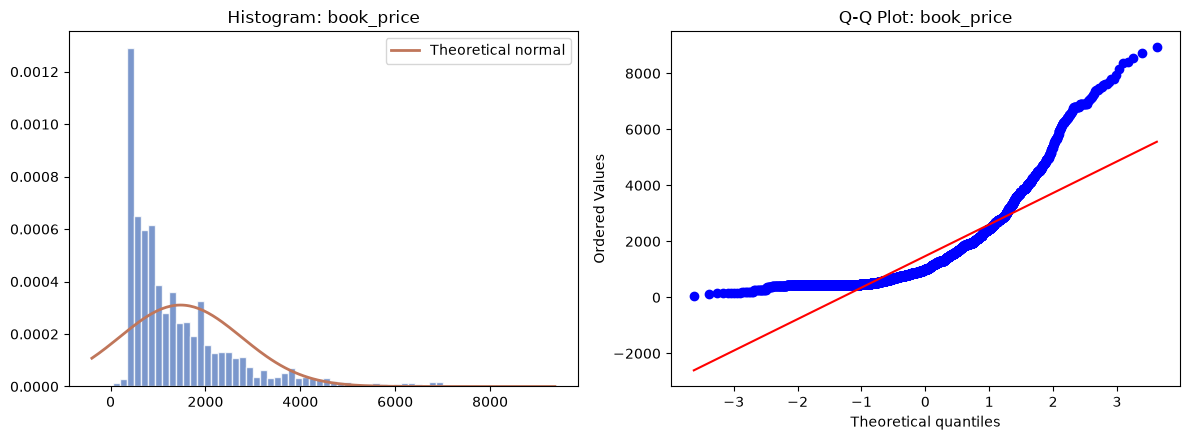



VARIABLE: rate_per_mile (n = 4783)
Skewness: 12.777  (right-skewed)
Excess Kurtosis: 253.173  (heavier tails than normal)

D'Agostino-Pearson test: statistic=8559.23, p-value=0.000000
-> Reject H0: the distribution is NOT normal (statistically significant, p < 0.05)
Shapiro-Wilk test (sample n=4783): statistic=0.3076, p-value=0.000000


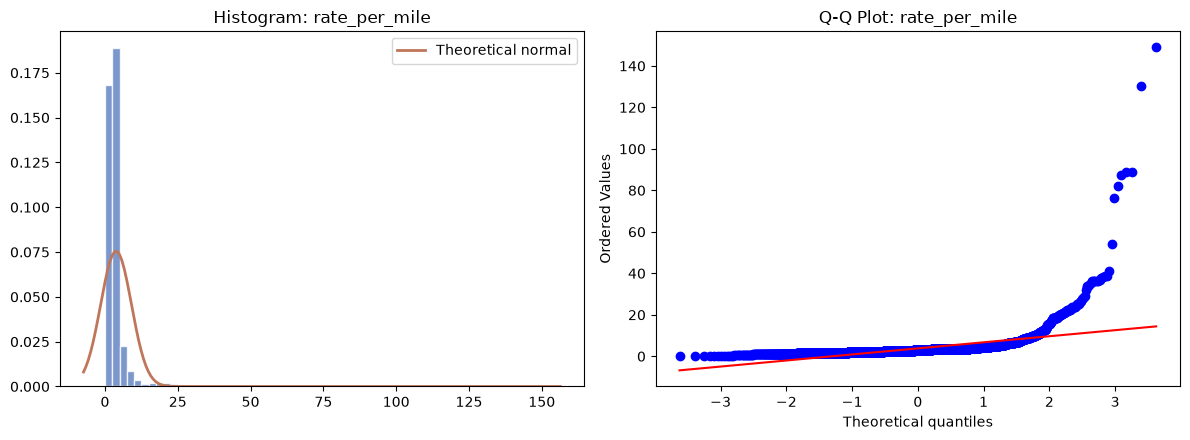

In [18]:
from scipy import stats
import matplotlib.pyplot as plt

# --- Prepares data (removes nulls, zeros, and cancelled loads, which skew the distribution) ---
active = df[(df['load_was_cancelled'] == False) & (df['mileage'] > 0) & (df['book_price'] > 0)].copy()
active['rate_per_mile'] = active['book_price'] / active['mileage']

variables = {
    'book_price': active['book_price'].dropna(),
    'rate_per_mile': active['rate_per_mile'].dropna()
}

for name, series in variables.items():
    print("=" * 70)
    print(f"VARIABLE: {name} (n = {len(series)})")
    print("=" * 70)

    # --- Distribution shape statistics ---
    skewness = stats.skew(series)
    kurt = stats.kurtosis(series)  # excess kurtosis (0 = normal)

    print(f"Skewness: {skewness:.3f}  "
          f"({'approximately symmetric' if abs(skewness) < 0.5 else 'right-skewed' if skewness > 0 else 'left-skewed'})")
    print(f"Excess Kurtosis: {kurt:.3f}  "
          f"({'close to normal' if abs(kurt) < 0.5 else 'heavier tails than normal' if kurt > 0 else 'lighter tails than normal'})")

    # --- Statistical normality test (D'Agostino-Pearson, works well for large n) ---
    stat, p_value = stats.normaltest(series)
    print(f"\nD'Agostino-Pearson test: statistic={stat:.2f}, p-value={p_value:.6f}")
    if p_value < 0.05:
        print("-> Reject H0: the distribution is NOT normal (statistically significant, p < 0.05)")
    else:
        print("-> Fail to reject H0: insufficient evidence to state it is not normal")

    # --- Shapiro-Wilk test (sample up to 5000, limit of the test) ---
    sample = series.sample(min(len(series), 5000), random_state=42)
    sw_stat, sw_p = stats.shapiro(sample)
    print(f"Shapiro-Wilk test (sample n={len(sample)}): statistic={sw_stat:.4f}, p-value={sw_p:.6f}")

    # --- Visualization: histogram + theoretical normal curve, and Q-Q plot ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].hist(series, bins=60, density=True, color='#5a7dc0', edgecolor='white', alpha=0.8)
    xmin, xmax = axes[0].get_xlim()
    x = np.linspace(xmin, xmax, 200)
    axes[0].plot(x, stats.norm.pdf(x, series.mean(), series.std()), color='#c0765a', linewidth=2, label='Theoretical normal')
    axes[0].set_title(f'Histogram: {name}')
    axes[0].legend()

    stats.probplot(series, dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot: {name}')

    plt.tight_layout()
    plt.show()
    print("\n")

In [19]:
print("Highest $/mile (very short hauls priced like full loads):")
active.nlargest(8, 'rate_per_mile')[
    ['loadsmart_id', 'lane', 'book_price', 'mileage', 'rate_per_mile']
]

Highest $/mile (very short hauls priced like full loads):


,loadsmart_id,lane,book_price,mileage,rate_per_mile
4789,206485777,"Conover,NC -> Newton,NC",387.10,2.6,148.884615
3519,206549601,"Conover,NC -> Claremont,NC",600.00,4.6,130.434783
3486,206499449,"Modesto,CA -> Modesto,CA",605.00,6.8,88.970588
2809,206426233,"Lathrop,CA -> Tracy,CA",852.15,9.6,88.765625
2837,206518833,"Lathrop,CA -> Tracy,CA",840.75,9.6,87.578125
2985,206523833,"Lathrop,CA -> Tracy,CA",787.87,9.6,82.069792
4797,206594161,"Conover,NC -> Claremont,NC",350.00,4.6,76.086957
2049,206550825,"Brooklyn,NY -> Jersey City,NJ",1244.05,22.9,54.325328


In [20]:
print("Lowest $/mile (likely broken/miskeyed prices):")
active.nsmallest(8, 'rate_per_mile')[
    ['loadsmart_id', 'lane', 'book_price', 'mileage', 'rate_per_mile']
]

Lowest $/mile (likely broken/miskeyed prices):


,loadsmart_id,lane,book_price,mileage,rate_per_mile
4820,206570401,"Decatur,IN -> Portland,OR",199.92,2278.0,0.087761
4830,206584729,"Rome City,IN -> Laceys Spring,AL",50.00,564.8,0.088527
4810,206622601,"Los Angeles,CA -> Newark,NJ",250.00,2785.5,0.089750
4815,206649585,"Lakewood,NY -> Laredo,TX",200.00,1750.8,0.114233
4828,206666745,"Plant City,FL -> Brook Park,OH",150.00,1089.1,0.137728
4817,206553785,"North Charleston,SC -> Laredo,TX",200.00,1445.9,0.138322
4819,206428505,"Del Rio,TX -> Mount Holly,NC",200.00,1376.5,0.145296
4804,206601193,"Fairfield,CA -> Rapid City,SD",250.00,1346.6,0.185653


In [21]:
# Largest losses and largest gains (extreme PnL)
cols = ['loadsmart_id', 'lane', 'book_price', 'source_price', 'pnl', 'mileage']

print("Largest losses:")
display(df.nsmallest(5, 'pnl')[cols])

print("\nLargest gains:")
display(df.nlargest(5, 'pnl')[cols])

Largest losses:


,loadsmart_id,lane,book_price,source_price,pnl,mileage
980,206590625,"Aurora,CO -> Grand Forks,ND",2125.56,5500.0,-3374.44,969.9
1297,206561817,"Trenton,MO -> Mount Holly,NC",1875.40,5200.0,-3324.60,964.8
1376,206497201,"Decatur,IN -> Mount Holly,NC",1781.30,5050.0,-3268.70,565.7
521,206430625,"Trenton,MO -> Cleveland,NC",2913.46,6000.0,-3086.54,972.4
454,206650393,"Sioux City,IA -> Pittston,PA",3190.00,6200.0,-3010.00,1188.1



Largest gains:


,loadsmart_id,lane,book_price,source_price,pnl,mileage
1,206521177,"Etowah,TN -> Reno,NV",8726.17,4000.0,4726.17,2331.3
85,206554737,"North Charleston,SC -> Laredo,TX",5955.26,2500.0,3455.26,1445.9
86,206510761,"North Charleston,SC -> Laredo,TX",5955.26,2500.0,3455.26,1445.9
3,206553113,"Montpelier,OH -> Reno,NV",8409.27,5000.0,3409.27,2082.3
84,206431201,"North Charleston,SC -> Laredo,TX",5984.31,2774.0,3210.31,1445.9


## 11. Mileage per Lane check

In [27]:
# Group mileage values seen per lane
lane_mileage = df.groupby('lane')['mileage'].unique()

# 1) Rows with mileage == 0
zero_mileage_rows = df[df['mileage'] == 0]
print(f"Rows with mileage == 0: {len(zero_mileage_rows)}")
zero_mileage_rows[['loadsmart_id', 'lane', 'mileage']]

Rows with mileage == 0: 47


,loadsmart_id,lane,mileage
6,206478177,"Maxton,NC -> Portland,OR",0.0
107,206606625,"Lakewood,NY -> Portland,OR",0.0
141,206569721,"Morganton,NC -> Reno,NV",0.0
213,206775177,"Paragould,AR -> Reno,NV",0.0
220,206561481,"Etowah,TN -> Reno,NV",0.0
385,206501801,"Batavia,IL -> Swedesboro,NJ",0.0
403,206643673,"Batavia,IL -> Swedesboro,NJ",0.0
470,206574889,"Batavia,IL -> Swedesboro,NJ",0.0
506,206423225,"North Charleston,SC -> Laredo,TX",0.0
512,206693913,"Rancho Cucamonga,CA -> Laredo,TX",0.0


In [19]:
import pandas as pd
from collections import Counter

# Excludes cancelled loads
df_active = df[df['load_was_cancelled'] == False]

# Groups by lane and calculates metrics with frequency counts
summary_df = df_active.groupby('lane')['mileage'].agg(
    mileage_values=lambda x: sorted(set(x)),
    all_values=lambda x: list(x),
    total_count='count',
    value_counts=lambda x: dict(Counter(x))  # Dictionary with {mileage: frequency}
).reset_index()

# Filters inconsistent lanes
summary_df['n_values'] = summary_df['mileage_values'].apply(len)
inconsistent_df_all = summary_df[summary_df['n_values'] > 1].copy()

# Adds auxiliary columns
inconsistent_df_all['has_zero'] = inconsistent_df_all['mileage_values'].apply(lambda v: 0 in v)
inconsistent_df_all['spread'] = inconsistent_df_all['mileage_values'].apply(lambda v: max(v) - min(v))
inconsistent_df_all = inconsistent_df_all.sort_values('spread', ascending=False)

# Reorders columns
columns_order = [
    'lane', 
    'mileage_values', 
    'n_values', 
    'value_counts',   # New column {100: 2, 120: 1}
    'all_values', 
    'total_count', 
    'has_zero', 
    'spread'
]
inconsistent_df_all = inconsistent_df_all[columns_order]

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(inconsistent_df_all)

,lane,mileage_values,n_values,value_counts,all_values,total_count,has_zero,spread
890,"Maxton,NC -> Portland,OR","[0.0, 2863.1]",2,"{2863.1: 3, 0.0: 1}","[2863.1, 0.0, 2863.1, 2863.1]",4,True,2863.1
23,"Aurora,CO -> Durango,CO","[344.0, 2987.8]",2,"{2987.8: 1, 344.0: 8}","[2987.8, 344.0, 344.0, 344.0, 344.0, 344.0, 344.0, 344.0, 344.0]",9,False,2643.8
807,"Lakewood,NY -> Portland,OR","[0.0, 2591.7]",2,"{2591.7: 4, 0.0: 1}","[2591.7, 2591.7, 2591.7, 2591.7, 0.0]",5,True,2591.7
922,"Morganton,NC -> Reno,NV","[0.0, 2487.3]",2,"{2487.3: 13, 0.0: 1}","[2487.3, 2487.3, 2487.3, 2487.3, 0.0, 2487.3, 2487.3, 2487.3, 2487.3, 2487.3, 2487.3, 2487.3, 2487.3, 2487.3]",14,True,2487.3
407,"Etowah,TN -> Reno,NV","[0.0, 2331.3]",2,"{2331.3: 8, 0.0: 1}","[2331.3, 2331.3, 2331.3, 2331.3, 2331.3, 2331.3, 0.0, 2331.3, 2331.3]",9,True,2331.3
1150,"Rancho Cucamonga,CA -> Laredo,TX","[0.0, 1464.4]",2,"{0.0: 1, 1464.4: 4}","[0.0, 1464.4, 1464.4, 1464.4, 1464.4]",5,True,1464.4
1024,"Ontario,CA -> Laredo,TX","[0.0, 1461.7]",2,"{1461.7: 8, 0.0: 1}","[1461.7, 1461.7, 1461.7, 1461.7, 1461.7, 1461.7, 1461.7, 1461.7, 0.0]",9,True,1461.7
1012,"North Charleston,SC -> Laredo,TX","[0.0, 1445.9]",2,"{1445.9: 33, 0.0: 1}","[1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 0.0, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9, 1445.9]",34,True,1445.9
1068,"Piedmont,SC -> Laredo,TX","[0.0, 1277.4]",2,"{1277.4: 18, 0.0: 3}","[1277.4, 1277.4, 1277.4, 1277.4, 1277.4, 1277.4, 1277.4, 1277.4, 1277.4, 1277.4, 1277.4, 1277.4, 0.0, 1277.4, 1277.4, 0.0, 1277.4, 1277.4, 0.0, 1277.4, 1277.4]",21,True,1277.4
541,"Granite City,IL -> Dowagiac,MI","[370.4, 1500.5]",2,"{1500.5: 1, 370.4: 1}","[1500.5, 370.4]",2,False,1130.1
